<a href="https://colab.research.google.com/github/juannMGC/Trabajo-de-Grado/blob/main/PropuestaTGRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

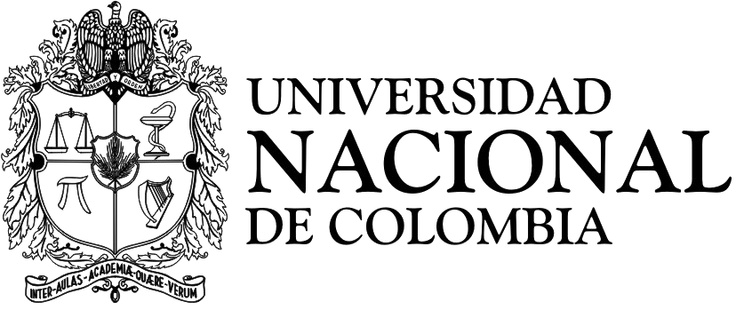
# **Proyecto Final: Machine Learning para predecir el impacto de la calidad del aire en la salud en Manizales.**

**Autor:** Juan Manuel Garcia Cifuentes

**Correo:** jugarciaci@unal.edu.co

In [434]:
# LIBRERÍAS ESTÁNDAR
import joblib

#  MANIPULACIÓN DE DATOS
import numpy as np
import pandas as pd

# VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# PREPROCESAMIENTO
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RepeatedStratifiedKFold,
    cross_val_score
)

# MODELOS
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    AdaBoostClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# MÉTRICAS
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    r2_score
)

# BALANCEO
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [435]:
df = pd.read_excel('BD_impacto_salud.xlsx')
df.head()

,ICA,PM_10,PM2_5,SO2,O3,Temperatura,Humedad,VelocidadViento,IngresosHospitalariosR,ConsultaHospitalariosR,IngresosHospitalariosC,ConsultaHospitalariosC,PuntuacionImpactoSalud,ClaseImpactoSalud
0,NaN,15.0,260,640.0,240.0,17.7,84.3,1.3,1.0,2,1,1.0,0.000000,4
1,1.0,12.0,270,60.0,30.0,18.4,84.1,1.1,1.0,1,1,7.0,18.828335,4
2,2.0,14.0,30,680.0,40.0,19.3,79.3,1.2,1.0,1,1,1.0,17.383685,4
3,1.0,19.0,330,780.0,20.0,19.1,79.6,0.6,1.0,6,1,7.0,24.654003,3
4,1.0,10.0,260,520.0,170.0,16.7,92.5,1.0,2.0,3,2,4.0,23.202835,3


In [436]:
hist = go.Figure(data=[go.Histogram(x=df['ClaseImpactoSalud'])])
hist.show()

In [437]:
df.dropna(inplace=True)

In [438]:
feature_list = df.columns.tolist()

In [439]:
df = df.astype(float)

In [440]:
df.dtypes

,0
ICA,float64
PM_10,float64
PM2_5,float64
SO2,float64
O3,float64
Temperatura,float64
Humedad,float64
VelocidadViento,float64
IngresosHospitalariosR,float64
ConsultaHospitalariosR,float64


Imputacion de Valores NaN

In [441]:
imputer = SimpleImputer(strategy='mean')

In [442]:
df_new = imputer.fit_transform(df)

In [443]:
df_new = pd.DataFrame(df_new)

In [444]:
df_new.columns = feature_list

In [445]:
df_new.head(10)

,ICA,PM_10,PM2_5,SO2,O3,Temperatura,Humedad,VelocidadViento,IngresosHospitalariosR,ConsultaHospitalariosR,IngresosHospitalariosC,ConsultaHospitalariosC,PuntuacionImpactoSalud,ClaseImpactoSalud
0,1.0,12.0,270.0,60.0,30.0,18.4,84.1,1.1,1.0,1.0,1.0,7.0,18.828335,4.0
1,2.0,14.0,30.0,680.0,40.0,19.3,79.3,1.2,1.0,1.0,1.0,1.0,17.383685,4.0
2,1.0,19.0,330.0,780.0,20.0,19.1,79.6,0.6,1.0,6.0,1.0,7.0,24.654003,3.0
3,1.0,10.0,260.0,520.0,170.0,16.7,92.5,1.0,2.0,3.0,2.0,4.0,23.202835,3.0
4,1.0,14.0,230.0,50.0,30.0,18.1,85.2,1.4,1.0,2.0,1.0,3.0,17.514623,4.0
5,1.0,15.0,240.0,50.0,360.0,18.6,83.3,1.2,1.0,3.0,1.0,1.0,18.662483,4.0
6,2.0,18.0,240.0,70.0,190.0,18.3,80.2,1.0,1.0,1.0,1.0,3.0,19.485756,4.0
7,1.0,18.0,320.0,750.0,160.0,18.2,78.1,0.9,1.0,1.0,2.0,4.0,24.847360,3.0
8,1.0,12.0,220.0,80.0,270.0,17.7,84.7,0.8,3.0,1.0,1.0,1.0,19.620551,4.0
9,2.0,12.0,20.0,720.0,30.0,17.1,84.7,0.9,1.0,3.0,2.0,2.0,18.405497,4.0


**Selección e ingeniería de características**

In [446]:
df_new['ClaseImpactoSalud'].value_counts()

,count
ClaseImpactoSalud,
3.0,414
4.0,187
2.0,5


In [447]:
df_new['ClaseImpactoSalud'] = df_new.sum(axis=1)/len(df_new.columns)

In [448]:
df_new['ClaseImpactoSalud'] = df_new['ClaseImpactoSalud'].apply(lambda x: int(x))

In [449]:
hist = go.Figure(data=[go.Histogram(x=df_new['ClaseImpactoSalud'])])
hist.show()

In [450]:
df_new.head()

,ICA,PM_10,PM2_5,SO2,O3,Temperatura,Humedad,VelocidadViento,IngresosHospitalariosR,ConsultaHospitalariosR,IngresosHospitalariosC,ConsultaHospitalariosC,PuntuacionImpactoSalud,ClaseImpactoSalud
0,1.0,12.0,270.0,60.0,30.0,18.4,84.1,1.1,1.0,1.0,1.0,7.0,18.828335,36
1,2.0,14.0,30.0,680.0,40.0,19.3,79.3,1.2,1.0,1.0,1.0,1.0,17.383685,63
2,1.0,19.0,330.0,780.0,20.0,19.1,79.6,0.6,1.0,6.0,1.0,7.0,24.654003,92
3,1.0,10.0,260.0,520.0,170.0,16.7,92.5,1.0,2.0,3.0,2.0,4.0,23.202835,79
4,1.0,14.0,230.0,50.0,30.0,18.1,85.2,1.4,1.0,2.0,1.0,3.0,17.514623,32


In [451]:
df_new.sort_values(by='ClaseImpactoSalud', ascending=False)

,ICA,PM_10,PM2_5,SO2,O3,Temperatura,Humedad,VelocidadViento,IngresosHospitalariosR,ConsultaHospitalariosR,IngresosHospitalariosC,ConsultaHospitalariosC,PuntuacionImpactoSalud,ClaseImpactoSalud
416,3.0,17.0,1000.0,1000.0,300.0,15.1,96.5,1.0,1.0,1.0,1.0,1.0,36.132729,176
225,5.0,18.0,1000.0,970.0,160.0,18.6,86.7,1.2,1.0,3.0,2.0,3.0,39.996511,165
19,2.0,22.0,560.0,770.0,770.0,16.2,87.1,0.8,1.0,5.0,1.0,3.0,31.663395,162
275,3.0,24.0,1000.0,710.0,270.0,16.9,91.5,1.0,3.0,1.0,2.0,1.0,40.741058,154
388,3.0,27.0,870.0,990.0,40.0,16.2,88.8,0.1,1.0,1.0,1.0,12.0,38.044364,149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,3.0,10.0,20.0,30.0,20.0,18.8,86.3,1.1,2.0,1.0,2.0,1.0,16.845225,15
350,4.0,17.0,10.0,10.0,40.0,17.7,87.0,1.2,1.0,2.0,1.0,1.0,16.014972,15
359,3.0,14.0,10.0,10.0,20.0,16.6,88.9,1.0,1.0,18.0,1.0,2.0,15.786705,14
365,3.0,13.0,20.0,10.0,20.0,16.7,89.6,1.3,1.0,2.0,1.0,1.0,14.420609,14


In [452]:
def clase_impacto_salud(score):
    if score <= 20:
        return "Muy bajo"
    elif score <= 40:
        return "Bajo"
    elif score <= 60:
        return "Moderado"
    elif score <= 80:
        return "Alto"
    else:
        return "Muy alto"

In [453]:
df_new['new_ClaseImpactoSalud'] = df_new['ClaseImpactoSalud'].apply(lambda x: clase_impacto_salud(x))

In [454]:
df_new.head(5)

,ICA,PM_10,PM2_5,SO2,O3,Temperatura,Humedad,VelocidadViento,IngresosHospitalariosR,ConsultaHospitalariosR,IngresosHospitalariosC,ConsultaHospitalariosC,PuntuacionImpactoSalud,ClaseImpactoSalud,new_ClaseImpactoSalud
0,1.0,12.0,270.0,60.0,30.0,18.4,84.1,1.1,1.0,1.0,1.0,7.0,18.828335,36,Bajo
1,2.0,14.0,30.0,680.0,40.0,19.3,79.3,1.2,1.0,1.0,1.0,1.0,17.383685,63,Alto
2,1.0,19.0,330.0,780.0,20.0,19.1,79.6,0.6,1.0,6.0,1.0,7.0,24.654003,92,Muy alto
3,1.0,10.0,260.0,520.0,170.0,16.7,92.5,1.0,2.0,3.0,2.0,4.0,23.202835,79,Alto
4,1.0,14.0,230.0,50.0,30.0,18.1,85.2,1.4,1.0,2.0,1.0,3.0,17.514623,32,Bajo


In [455]:
df_new['new_ClaseImpactoSalud'].value_counts()

,count
new_ClaseImpactoSalud,
Moderado,179
Alto,155
Muy alto,147
Muy bajo,69
Bajo,56


In [456]:
df_imbalance = df_new['new_ClaseImpactoSalud'].value_counts()

In [457]:
df_imbalance = pd.DataFrame(df_imbalance).reset_index()
df_imbalance.columns = ['Class', 'Instances']
df_imbalance

,Class,Instances
0,Moderado,179
1,Alto,155
2,Muy alto,147
3,Muy bajo,69
4,Bajo,56


**Data Imbalance**

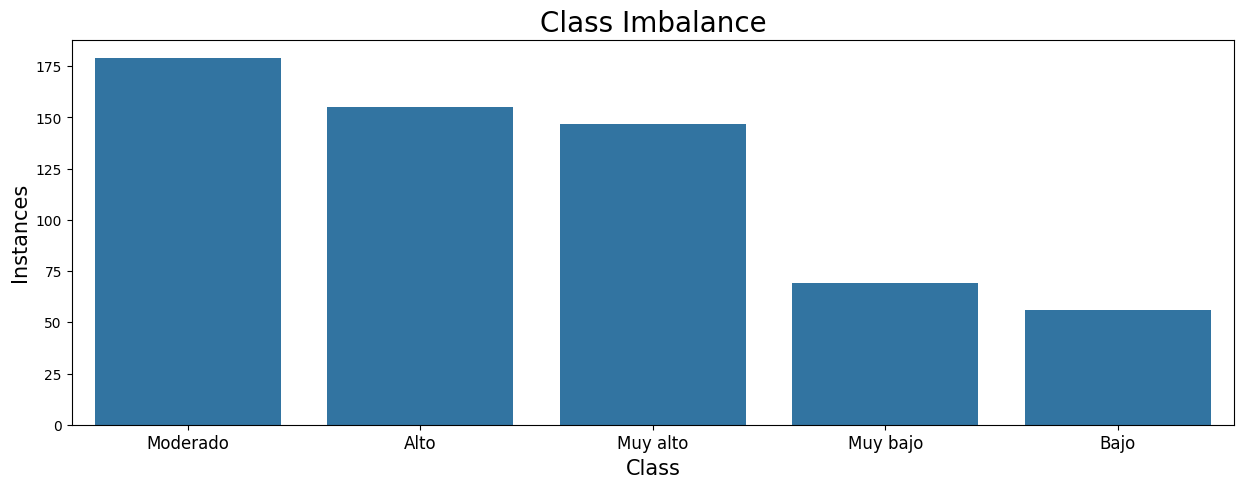

In [458]:
plt.subplots(figsize=(15,5))
sns.barplot(x='Class',y='Instances',data=df_imbalance)
plt.ylabel('Instances', fontsize=15)
plt.xticks(rotation=0,fontsize=12)
plt.xlabel('Class', fontsize=15)
plt.title('Class Imbalance', fontsize=20)
plt.show()

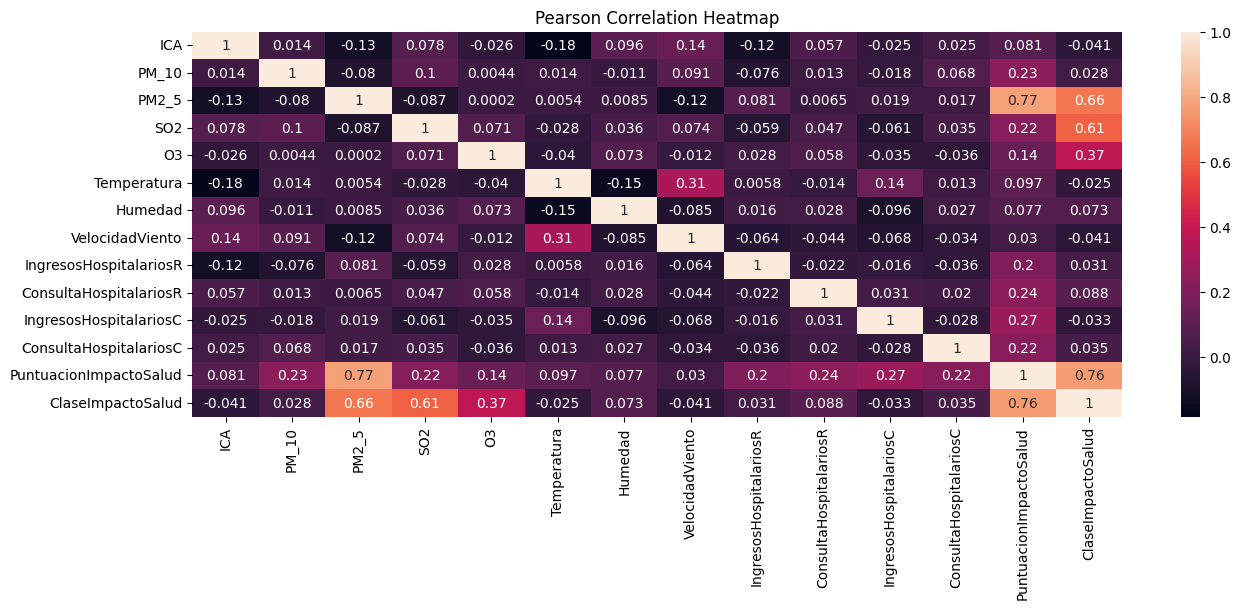

In [459]:
fig = plt.figure(figsize = (15, 5))
sns.heatmap(df_new.drop(columns=['new_ClaseImpactoSalud']).corr(), annot=True)
plt.title('Pearson Correlation Heatmap')
plt.show()

In [460]:
df_new = df_new[df_new.iloc[:, -1] != "Muy bajo"]

In [461]:
X = df_new.iloc[:, : -2]
y = df_new.iloc[:, -1]
#y = encoder.fit_transform(y)

In [462]:
rfc = RandomForestClassifier(n_estimators=100, max_depth=3)

scaler = StandardScaler()
encoder = LabelEncoder()

In [463]:
X_scaled = scaler.fit_transform(X)

In [464]:
xtrain, xtest, ytrain, ytest = train_test_split(X_scaled, y, test_size=0.3, random_state=0)

In [465]:
rfc.fit(xtrain, ytrain)
pred = rfc.predict(xtest)

In [466]:
accuracy_score(ytest, pred)

0.7530864197530864

In [467]:
print(classification_report(ytest, pred))

              precision    recall  f1-score   support

        Alto       0.83      0.51      0.63        49
        Bajo       0.00      0.00      0.00        12
    Moderado       0.66      1.00      0.79        54
    Muy alto       0.86      0.91      0.89        47

    accuracy                           0.75       162
   macro avg       0.59      0.61      0.58       162
weighted avg       0.72      0.75      0.71       162



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [468]:
roc = roc_auc_score(ytest, rfc.predict_proba(xtest), multi_class='ovr')
print("ROC AUC:", round(roc, 4))

ROC AUC: 0.9198


In [469]:
f1_score(ytest, pred, average='weighted')

0.7133649028506671

**Oversampling using SMOTE**

In [470]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

In [471]:
y_res.value_counts()

,count
new_ClaseImpactoSalud,
Bajo,179
Alto,179
Muy alto,179
Moderado,179


In [472]:
X_res.shape

(716, 13)

In [473]:
X_scaled = scaler.fit_transform(X_res)
xtrain, xtest, ytrain, ytest = train_test_split(X_scaled, y_res, test_size=0.3, random_state=0)
rfc = RandomForestClassifier(n_estimators=100, max_depth=3, n_jobs=-1, random_state=0)
rfc.fit(xtrain, ytrain)
pred = rfc.predict(xtest)
print('Accuracy: {}'.format(accuracy_score(ytest, pred)))
print('F1-Score: {}'.format(f1_score(ytest, pred, average='weighted')))
print(classification_report(ytest, pred))
# print('AUC score: {}'.format(roc_auc_score(ytest, rfc.predict_proba(xtest), multi_class='ovr')))

Accuracy: 0.7069767441860465
F1-Score: 0.7018557228699059
              precision    recall  f1-score   support

        Alto       0.62      0.55      0.58        56
        Bajo       0.70      0.98      0.82        41
    Moderado       0.70      0.67      0.68        63
    Muy alto       0.81      0.71      0.76        55

    accuracy                           0.71       215
   macro avg       0.71      0.73      0.71       215
weighted avg       0.71      0.71      0.70       215



**Oversampling + Stratified sampling**

In [474]:
X_scaled = scaler.fit_transform(X_res)
xtrain, xtest, ytrain, ytest = train_test_split(X_scaled, y_res, test_size=0.3, stratify=y_res, random_state=0)
rfc = RandomForestClassifier(n_estimators=150, max_depth=3, n_jobs=-1, random_state=0)
rfc.fit(xtrain, ytrain)
pred = rfc.predict(xtest)
print('Train Accuracy: {}'.format(accuracy_score(ytrain, rfc.predict(xtrain))))
print('Test Accuracy: {}'.format(accuracy_score(ytest, pred)))
print('F1-Score: {}'.format(f1_score(ytest, pred, average='weighted')))
print(classification_report(ytest, pred))
# print('AUC score: {}'.format(roc_auc_score(ytest, rfc.predict_proba(xtest), multi_class='ovr')))

Train Accuracy: 0.8083832335329342
Test Accuracy: 0.7302325581395349
F1-Score: 0.7162072715701319
              precision    recall  f1-score   support

        Alto       0.61      0.41      0.49        54
        Bajo       0.83      1.00      0.91        54
    Moderado       0.66      0.75      0.70        53
    Muy alto       0.77      0.76      0.77        54

    accuracy                           0.73       215
   macro avg       0.72      0.73      0.72       215
weighted avg       0.72      0.73      0.72       215



In [475]:
clf = AdaBoostClassifier(n_estimators=1000, random_state=0, learning_rate=2.2)
clf.fit(xtrain, ytrain)
pred = clf.predict(xtest)

In [476]:
print('Train Accuracy: {}'.format(accuracy_score(ytrain, clf.predict(xtrain))))
print('Test Accuracy: {}'.format(accuracy_score(ytest, pred)))
print('F1-Score: {}'.format(f1_score(ytest, pred, average='weighted')))
print(classification_report(ytest, pred))
# print('AUC score: {}'.format(roc_auc_score(ytest, rfc.predict_proba(xtest), multi_class='ovr')))

Train Accuracy: 0.8143712574850299
Test Accuracy: 0.6790697674418604
F1-Score: 0.6810353038239996
              precision    recall  f1-score   support

        Alto       0.59      0.85      0.70        54
        Bajo       0.90      0.52      0.66        54
    Moderado       0.56      0.74      0.63        53
    Muy alto       0.92      0.61      0.73        54

    accuracy                           0.68       215
   macro avg       0.74      0.68      0.68       215
weighted avg       0.74      0.68      0.68       215



**Creacion de pipeline**


In [477]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)# Validación cruzada

ada = AdaBoostClassifier()
pipe_ada = Pipeline([('model', ada)])# Pipeline
scores_ada = cross_val_score(pipe_ada, X, y, scoring='accuracy', cv=cv, n_jobs=-1)# Evaluación

knn = KNeighborsClassifier()
pipe_knn = Pipeline([('scaler', scaler), ('model', knn)])
scores_knn = cross_val_score(pipe_knn, X,y, scoring= 'accuracy',cv =cv, n_jobs=-1)

rf = RandomForestClassifier()
pipe_rf = Pipeline([('model', rf)])
scores_rf = cross_val_score(pipe_rf, X,y, scoring= 'accuracy',cv =cv, n_jobs=-1)

svc = SVC(gamma='scale', C=1, kernel='rbf')
pipe_svc = Pipeline([('scaler', scaler), ('model', svc)])
scores_svc = cross_val_score(pipe_svc, X,y, scoring= 'accuracy',cv =cv, n_jobs=-1)

mlp = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=0)
pipe_mlp = Pipeline([('scaler', scaler), ('model', mlp)])
scores_mlp = cross_val_score(pipe_mlp, X,y, scoring= 'accuracy',cv =cv, n_jobs=-1)

**Selección de modelos y ajuste de hiperparámetros mediante GridSearchCV**

In [478]:
model_params = {

    'Random Forest': {
        'model': pipe_rf,
        'params': {
            'model__n_estimators': [100, 200],
            'model__max_depth': [5, 8],
            'model__min_samples_split': [2, 5]
        }
    },

    'SVC': {
        'model': pipe_svc,
        'params': {
            'model__C': [1, 10],
            'model__kernel': ['rbf', 'linear'],
            'model__gamma': ['scale', 'auto']
        }
    },

    'AdaBoost': {
        'model': pipe_ada,
        'params': {
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.5, 1.0]
        }
    },

    'KNN': {
        'model': pipe_knn,
        'params': {
            'model__n_neighbors': [3, 5, 7],
            'model__p': [1, 2]
        }
    },

    'MLP': {
        'model': pipe_mlp,
        'params': {
            'model__hidden_layer_sizes': [(50,), (100,), (100,50)],
            'model__activation': ['relu', 'tanh'],
            'model__alpha': [0.0001, 0.001],
            'model__learning_rate_init': [0.001]
        }
    }
}

In [479]:
model_scores = []

for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=cv, return_train_score=False, n_jobs=-1)
    clf.fit(xtrain, ytrain)
    ypred = clf.predict(xtest)
    model_scores.append({
        'Model': model_name,
        'Best parameters': clf.best_params_,
        'Train score': clf.best_score_,
        'Test score': accuracy_score(ytest, ypred)

    })

print(model_scores)

[{'Model': 'Random Forest', 'Best parameters': {'model__max_depth': 8, 'model__min_samples_split': 2, 'model__n_estimators': 200}, 'Train score': np.float64(0.8409019607843136), 'Test score': 0.827906976744186}, {'Model': 'SVC', 'Best parameters': {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}, 'Train score': np.float64(0.9434117647058826), 'Test score': 0.958139534883721}, {'Model': 'AdaBoost', 'Best parameters': {'model__learning_rate': 0.5, 'model__n_estimators': 100}, 'Train score': np.float64(0.6221176470588236), 'Test score': 0.6}, {'Model': 'KNN', 'Best parameters': {'model__n_neighbors': 3, 'model__p': 1}, 'Train score': np.float64(0.7458431372549017), 'Test score': 0.7209302325581395}, {'Model': 'MLP', 'Best parameters': {'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100, 50), 'model__learning_rate_init': 0.001}, 'Train score': np.float64(0.9467189542483663), 'Test score': 0.9302325581395349}]


In [480]:
bm = pd.DataFrame(model_scores)
bm = bm.sort_values(by='Test score', ascending=False)
bm

,Model,Best parameters,Train score,Test score
1,SVC,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.943412,0.958140
4,MLP,"{'model__activation': 'tanh', 'model__alpha': ...",0.946719,0.930233
0,Random Forest,"{'model__max_depth': 8, 'model__min_samples_sp...",0.840902,0.827907
3,KNN,"{'model__n_neighbors': 3, 'model__p': 1}",0.745843,0.720930
2,AdaBoost,"{'model__learning_rate': 0.5, 'model__n_estima...",0.622118,0.600000


In [481]:
colors = ['lightslategray',] * 5
colors[1] = 'crimson'

y = round(bm['Test score'], 4)
x = bm['Model']

# Use textposition='auto' for direct text
fig = go.Figure(data=[go.Bar(
            x=x, y=y,
            text=y,
            textposition='outside', orientation = 'v', marker_color=colors
        )])

# fig.update_layout(
#     autosize=False,
#     width=800,
#     height=500)

fig.update_layout(title_text='Model Comparison',
                 xaxis_title="Model",
                 yaxis_title="Test Score",)


fig.show()

In [482]:
# plt.subplots(figsize=(12,10))
# g = sns.barplot(x='Test score', y='Model', data=bm, palette='inferno', edgecolor=sns.color_palette('dark',10), )
# g.text(bm['Test score'], bm['Model'], round(bm['Test score'],4), color='black', ha="center")
# plt.ylabel('Model', fontsize=15)
# plt.xticks(rotation=45,fontsize=20)
# plt.xlabel('Test Score', fontsize=15)
# plt.title('Best Model', fontsize=24)
# plt.savefig('best_model.png')
# plt.show()

In [483]:
ada = AdaBoostClassifier(n_estimators=200, learning_rate=1.0, random_state=1)
rf = RandomForestClassifier(n_estimators=200, max_depth=8)
knn = KNeighborsClassifier(n_neighbors=1, leaf_size=1, p=1)
svc = SVC(C=1,kernel='rbf',gamma='scale',probability=True,random_state=1)
mlp = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=0)

In [484]:
# AdaBoost
scores = cross_val_score(ada, xtest, ytest, scoring='accuracy', cv=cv, n_jobs=-1)
np.mean(scores)

np.float64(0.592929292929293)

In [485]:
#Random Forest
scores = cross_val_score(rf, xtest, ytest, scoring= 'accuracy', cv =cv, n_jobs=-1)
np.mean(scores)

np.float64(0.8090187590187592)

In [486]:
#KNN
scores = cross_val_score(knn, xtest, ytest, scoring= 'accuracy', cv =cv, n_jobs=-1)
np.mean(scores)

np.float64(0.6915584415584417)

In [487]:
#Red neuronal
scores = cross_val_score(mlp, xtest, ytest, scoring= 'accuracy', cv =cv, n_jobs=-1)
np.mean(scores)

np.float64(0.8481962481962483)

In [488]:
#SVC
scores = cross_val_score(svc, xtest, ytest, scoring= 'accuracy', cv =cv, n_jobs=-1)
np.mean(scores)

np.float64(0.7764069264069264)

**Evaluación del modelo final**

In [489]:
mlp = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=0)

In [490]:
mlp.fit(xtrain, ytrain)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=0)

In [491]:
ypred = mlp.predict(xtest)

In [492]:
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

        Alto       0.88      0.91      0.89        54
        Bajo       0.96      0.85      0.90        54
    Moderado       0.83      0.92      0.88        53
    Muy alto       0.94      0.91      0.92        54

    accuracy                           0.90       215
   macro avg       0.90      0.90      0.90       215
weighted avg       0.90      0.90      0.90       215



In [493]:
print(accuracy_score(ytest, ypred))

0.8976744186046511


In [494]:
print(f1_score(ytest, ypred, average='weighted'))

0.8982069840182273


In [495]:
# Guardar el ganador absoluto para la App
mejor_modelo_final = mlp
joblib.dump(mejor_modelo_final, 'mejor_modelo_v1.pkl')
joblib.dump(scaler, 'scaler_v1.pkl')
joblib.dump(encoder, 'label_encoder_v1.pkl')
joblib.dump(X.columns, 'features_v1.pkl')

['features_v1.pkl']

#7. VISUALIZACION EN STREAMLIT

In [496]:
!pip install streamlit
!pip install streamlit-lottie
!pip install pyngrok

In [497]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import requests
from streamlit_lottie import st_lottie

# CONFIGURACIÓN GENERAL
st.set_page_config(
    page_title="Investigación Aire Manizales",
    layout="wide",
    page_icon="🏔️"
)

# FUNCIÓN PARA CARGAR ANIMACIONES
def cargar_lottie_url(url):
    try:
        r = requests.get(url)
        if r.status_code == 200:
            return r.json()
        return None
    except:
        return None

lottie_salud = cargar_lottie_url(
    "https://lottie.host/3d5ee517-de54-4bf5-a42f-8c87c929dc5c/Bk2pUIGElP.json"
)
lottie_salud1 = cargar_lottie_url(
    "https://lottie.host/95af0ede-15a3-4890-a1dd-1063b49e88cb/Vik32cUg12.json"
)

# ESTILOS PERSONALIZADOS
st.markdown("""
<style>
.main { background-color: #f8f9fa; }
.stMetric {
    background-color: white;
    padding: 20px;
    border-radius: 10px;
    box-shadow: 0 2px 4px rgba(0,0,0,0.05);
}
</style>
""", unsafe_allow_html=True)

# CARGA SEGURA DEL MODELO
@st.cache_resource
def load_assets():
    try:
        model = joblib.load("mejor_modelo_v1.pkl")
        scaler = joblib.load("scaler_v1.pkl")
        features = joblib.load("features_v1.pkl")
        return model, scaler, features, None
    except Exception as e:
        return None, None, None, str(e)

model, scaler, features, error = load_assets()

if error:
    st.error(f"⚠️ Error al cargar archivos: {error}")
    st.stop()

# SIDEBAR
with st.sidebar:
    st.title("Impacto de la calidad del aire en la salud en Manizales.")

    if lottie_salud:
        st_lottie(lottie_salud, height=150)

    st.write("Ajuste los niveles ambientales actuales.")

def get_user_inputs():
    input_dict = {}

    for col in features:
        if "Humedad" in col:
            input_dict[col] = st.sidebar.slider(f"{col} (%)", 0.0, 100.0, 70.0)
        elif "Temperatura" in col:
            input_dict[col] = st.sidebar.slider(f"{col} (°C)", 0.0, 45.0, 18.0)
        elif "Hospitalarios" in col or "Consulta" in col:
            input_dict[col] = st.sidebar.number_input(f"{col}", min_value=0, value=1)
        else:
            input_dict[col] = st.sidebar.slider(f"{col} (µg/m³)", 0.0, 500.0, 25.0)

    return pd.DataFrame([input_dict])[features]

df_input = get_user_inputs()

with st.sidebar:
    if lottie_salud1:
        st_lottie(lottie_salud1, height=150)

# CUERPO PRINCIPAL
st.title("Sistema Predictivo de Impacto en Salud")
st.markdown("""
Modelo de Machine Learning entrenado con datos ambientales
y registros históricos de salud pública en Manizales.
""")

col1, col2 = st.columns([1, 1])


# Mostrar parámetros
with col1:
    st.subheader("Parámetros Actuales")
    st.dataframe(
        df_input.T.rename(columns={0: "Valor Actual"}),
        use_container_width=True
    )

# Predicción
with col2:
    st.subheader("Clasificación del Impacto")

    try:
        # Escalado
        input_scaled = scaler.transform(df_input)

        # Predicción directa (sin encoder)
        label = model.predict(input_scaled)[0]

        # Probabilidades
        probs = model.predict_proba(input_scaled)[0]
        confianza = np.max(probs) * 100

        # Colores ICA
        colors = {
            "Buenas": "#28a745",
            "Moderada": "#f1c40f",
            "Dañina (Grupos Sensitivos)": "#fd7e14",
            "Dañina a la Salud": "#dc3545",
        }

        res_color = colors.get(label, "#007bff")

        # Tarjeta visual
        st.markdown(f"""
        <div style="
            background-color:{res_color};
            padding:40px;
            border-radius:20px;
            text-align:center;
            color:white;">
            <h1 style="font-size:3em;">{label}</h1>
            <p style="font-size:1.4em;">
            Nivel de Confianza: {confianza:.2f}%
            </p>
        </div>
        """, unsafe_allow_html=True)

        # Gráfico de probabilidades
        st.write("---")
        st.subheader("Análisis de Incertidumbre")

        prob_df = pd.DataFrame(
            probs,
            index=model.classes_,
            columns=["Probabilidad (%)"]
        )

        prob_df["Probabilidad (%)"] *= 100

        st.bar_chart(prob_df)

    except Exception as e:
        st.error(f"Error en la predicción: {e}")

# PIE DE PÁGINA
st.caption(
    "Investigación en Machine Learning aplicado a la Salud Ambiental - Manizales 2025"
)

# FONDO PERSONALIZADO
def set_background_image(url):
    st.markdown(
        f"""
        <style>
        .stApp {{
            background: url('{url}') no-repeat center center fixed;
            background-size: cover;
        }}
        </style>
        """,
        unsafe_allow_html=True
    )

set_background_image("https://i.morioh.com/52c215bc5f.png")

Writing app.py


In [500]:
import os
from pyngrok import ngrok
# IMPORTANT: Replace "YOUR_VALID_NGROK_AUTHTOKEN" with your actual authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
# This authtoken is necessary for ngrok to create a public tunnel.
ngrok.set_auth_token("2mtYHs82kdnyaMpvuUtSR7z3avo_3nc1wQKSHgUAg8cp7MhU7")

# Ejecutar Streamlit en segundo plano
os.system("streamlit run app.py &")

# Crear un túnel público con ngrok
# Streamlit runs on port 8501 by default
public_url = ngrok.connect(8501)
print(f"Tu aplicación está disponible en: {public_url}")

Tu aplicación está disponible en: NgrokTunnel: "https://13c8-136-118-248-97.ngrok-free.app" -> "http://localhost:8501"
